## Gradient data with Peltier on one side and RT on other

note: it was difficult to keep the RT side consistent, so analysis tries to take temperature gaps into account as well as whether the battery was heating or cooling

In [1]:
import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import ipywidgets

In [57]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = "/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.sqlite3"

# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'

data = pj.loadPickle("/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.pickle")
data['parameters']['dt'] = data['parameters']['measureTime']-data['parameters']['measureDelay'] *10-6/ data['parameters']['samples']

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/LMFP_Cu_gradient.pickle already exists. Conversion aborted.


In [63]:
(data['parameters']['measureTime']-data['parameters']['measureDelay'])/ data['parameters']['samples']

0.002

In [4]:
data['parameters']

{'gui': 0.0,
 'experiment': 'repeat pulse',
 'axis': 'z',
 'distance': 75.0,
 'transducerFrequency': 2.25,
 'collectionMode': 'transmission',
 'pulserType': 'standard',
 'measureTime': 20.0,
 'measureDelay': 0.0,
 'voltageRange': 2.0,
 'autoRange': 'True',
 'autoRangeEcho': 'True',
 'waves': 100.0,
 'samples': 10000.0,
 'halfCycles': 2.0,
 'multiplexer': 'False',
 'collectionDirection': 'both',
 'voltageOffsetForward': 0.0,
 'voltageOffsetReverse': 0.0,
 'gainForward': 500.0,
 'gainReverse': 500.0,
 'picoModule': 1.0,
 'pulseModule': 0.0,
 'rfSwitch': 2.0,
 't0PulseSwitch': 0.0,
 't0ReceiveSwitch': 0.0,
 't1PulseSwitch': 1.0,
 't1ReceiveSwitch': 1.0,
 'experimentFolder': 'C://Users//changlab//Desktop//UT Data//toy_data//',
 'experimentName': 'LMFP_Cu_gradient',
 'experimentBaseName': 'test_multiscan_data',
 'saveFormat': 'sqlite',
 'postAnalysis': 'False',
 'primaryAxis': 'X',
 'secondaryAxis': 'Z',
 'primaryAxisRange': 25.0,
 'primaryAxisStep': 1.0,
 'secondaryAxisRange': 25.0,
 'seco

In [6]:
data[0].keys()

dict_keys(['voltage', 'time', 'time_collected', 'collection_index'])

In [7]:
data['dt'] = (data['parameters']['measureTime']-data['parameters']['measureDelay'])/data['parameters']['samples']
data['dt']

0.002

## Merge the waveform and controller data wrt time that UT is running

In [18]:
def correct_voltage(dataframe):
    '''correct measurements by matching mean of 1st 25 pts to 0.
    '''
    for item in dataframe['voltage']:
        item -= item[:25].mean()
    return dataframe

In [ ]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
waveform_df = correct_voltage(waveform_df)
waveform_df

In [ ]:
## Read in monitor data, add ms to time
from datetime import datetime
controller_monitor_df = pd.read_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-16_19-14-58 (all)_Monitor.csv',
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '1000.1: CH1 Object', '1000.2: CH2 Object', # ###.#: is the firmware output for that channel.
                                        '1001.1: CH1 Sink', '1001.2: CH2 Sink',
                                        '1045.1: HR1 Temp', '1045.2: HR2 Temp',
                                        '1044.1: LR1 Temp', '1044.2: LR2 Temp',
                                        '3000.1: CH1 Target', '3000.2: CH2 Target',
                                    ])
controller_monitor_df['Time_str'] = controller_monitor_df['Time']
controller_monitor_df['Time'] = controller_monitor_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_monitor_df['Time'] += controller_monitor_df['Milliseconds']/1000
controller_monitor_df.drop(columns=['Milliseconds'], inplace=True)

## Read in settings data, add ms to time
controller_settings_df = pd.read_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-16_19-14-58 (all)_Settings.csv',

                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '2010.1: Output Enable', '2010.2: Output Enable', 
                                        '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
                                        '1200.1: Temperature is Stable','1200.2: Temperature is Stable'
                                    ])

# to correct later: PID params, max temperature change, )
controller_settings_df['Time'] = controller_settings_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_settings_df['Time'] += controller_settings_df['Milliseconds']/1000
controller_settings_df.drop(columns=['Milliseconds'], inplace=True)

## Merge monitor and settings data
controller_df = pd.merge_asof(
    left=controller_monitor_df,
    right=controller_settings_df,
    left_on='Time',
    right_on='Time',
    direction='nearest' 
)
## Convert time to float in all dfs
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_monitor_df['Time'] = controller_monitor_df['Time'].astype(float)
controller_settings_df['Time'] = controller_settings_df['Time'].astype(float)

## Merge waveform and controller data
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)
## reformat time Time_str to '%m/%d/%y %H:%M:%S'
merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')
merged_df.to_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/merged_df.csv')

In [52]:
merged_df.tail()

,voltage,time,time_collected,collection_index,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,1001.2: CH2 Sink,1044.1: LR1 Temp,...,1045.2: HR2 Temp,3000.1: CH1 Target,3000.2: CH2 Target,Time_str,1200.1: Temperature is Stable,1200.2: Temperature is Stable,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity
3592,"[0.7056471456692917, 0.6192175196850389, 0.100...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3592.0,1.781652e+09,17.570520,31.657495,34.166862,27.165308,34.166862,...,31.657495,17.0,43.0,06/16/26 19:12:39,1,0,ON,ON,Cooling,Cooling
3593,"[0.7295398622047244, 0.6000492125984245, -0.48...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3593.0,1.781652e+09,17.441278,32.011375,34.096581,27.103754,34.096581,...,32.011375,17.0,43.0,06/16/26 19:12:40,1,0,ON,ON,Cooling,Cooling
3594,"[0.6639333169291337, 0.8800073818897642, 0.274...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3594.0,1.781652e+09,16.882532,32.342278,34.029167,27.043238,34.029167,...,32.342278,17.0,43.0,06/16/26 19:12:41,1,0,ON,ON,Cooling,Cooling
3595,"[0.9661724901574806, 0.3614726870078737, 0.188...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3595.0,1.781652e+09,17.567316,32.734367,33.961998,26.984400,33.961998,...,32.734367,17.0,43.0,06/16/26 19:12:42,1,0,ON,ON,Cooling,Cooling
3596,"[0.39613065944881853, 0.8716473917322829, -0.0...","[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16...",1.781652e+09,3596.0,1.781652e+09,17.546747,33.140373,33.892967,26.924463,33.892967,...,33.140373,17.0,43.0,06/16/26 19:12:43,1,0,ON,ON,Cooling,Cooling


## Compare Curves of gradients vs means

In [64]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm

def plot_waveform(i):
    plt.figure(figsize=(8, 4))
    plt.plot(merged_df['time'][i], merged_df['voltage'][i], lw=1)
    plt.title(f'Measurement {i} at ({merged_df["Time_str"][i]})')
    plt.xlabel('Time (ns)')
    plt.ylabel('Voltage (mV)')
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_waveform, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=3596), Outpu…

<function __main__.plot_waveform(i)>

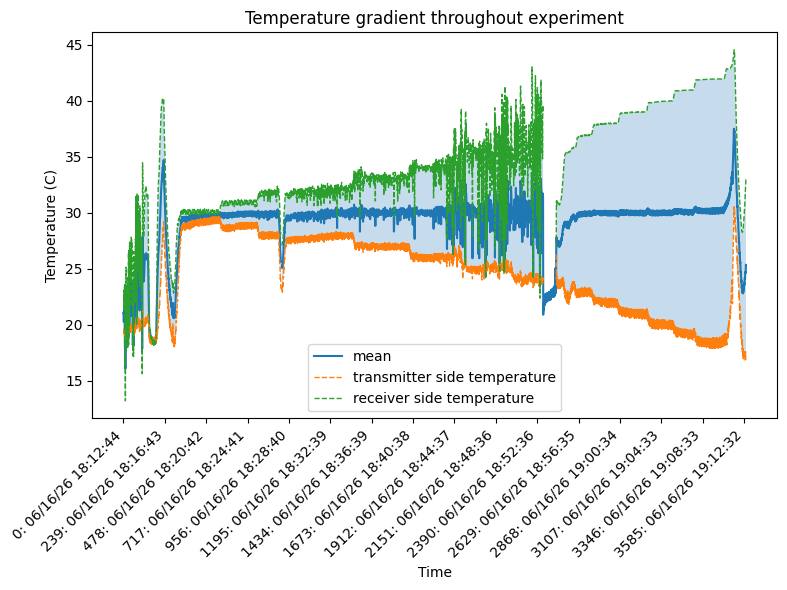

In [65]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

merged_df['index'] = merged_df.index
merged_df['means'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff'] = merged_df['1000.2: CH2 Object'] - merged_df['1000.1: CH1 Object']

xticks_labels = merged_df['index'].astype(str) + ': ' + merged_df['Time_str']

plt.figure(figsize=(8, 6))
# plt.plot(xticks_labels, merged_df['diff'], label='difference')
plt.plot(xticks_labels, merged_df['means'], label='mean')
lower_bound = merged_df['means'] - merged_df['diff'] / 2
plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
upper_bound = merged_df['means'] + merged_df['diff'] / 2
plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')

plt.fill_between(
    xticks_labels,
    lower_bound,
    upper_bound,  # Upper half
    alpha=0.25,
    )

plt.title('Temperature gradient throughout experiment')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.legend()
plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Filter out outliers (+/- 5 from target)

In [70]:
(merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs()


0        2.460382
1        2.460382
2        1.391870
3        3.096247
4        2.529444
          ...    
3592    11.342505
3593    10.988625
3594    10.657722
3595    10.265633
3596     9.859627
Length: 3597, dtype: float64

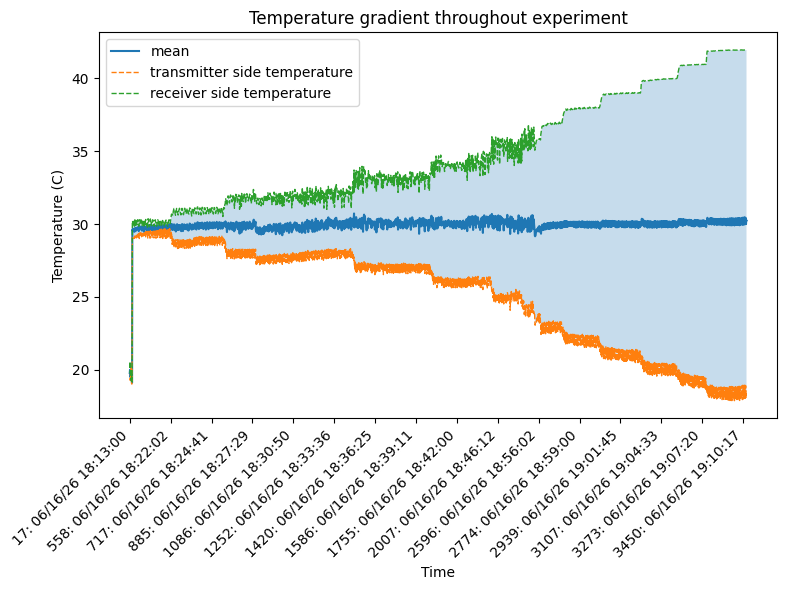

In [72]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

mask = ( (merged_df['1000.1: CH1 Object'] - merged_df['3000.1: CH1 Target']).abs() < 1  
   ) & ( (merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs() < 1 )

merged_filtered_df = merged_df.loc[mask].copy()

xticks_labels = merged_filtered_df['index'].astype(str) + ': ' + merged_filtered_df['Time_str']

plt.figure(figsize=(8, 6))
# plt.plot(xticks_labels, merged_df['diff'], label='difference')
plt.plot(xticks_labels, merged_filtered_df['means'], label='mean')
lower_bound = merged_filtered_df['means'] - merged_filtered_df['diff'] / 2
plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
upper_bound = merged_filtered_df['means'] + merged_filtered_df['diff'] / 2
plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')

plt.fill_between(
    xticks_labels,
    lower_bound,
    upper_bound,  # Upper half
    alpha=0.25,
    )

plt.title('Temperature gradient throughout experiment')
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.legend()
plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## filtered by mean temperature

In [19]:
index_range = (1000,1796)
ranged_df_ = merged_df.loc[index_range[0]:index_range[1]]

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def matplotlib_constrain_T(
    t1=0, t2=100, g1=0, g2=100, heating='both', sort_by='diff',
    index_range=None, direction='forward', separate_diff_lines=False,
    samples=None,
    save_fig_title='gradient.svg'):

    '''
    heating is on, off, or both
    sort_by is 'diff' or 'means'
    index_range is a tuple of (start, end). You can look at the above plot to decide range
    direction is 'forward', 'reverse', or 'both'. Forward is when pulse goes from cold side
    '''
    # Select range
    if index_range is not None: ranged_df = merged_df.loc[index_range[0]:index_range[1]].copy()
    else: ranged_df = merged_df.copy()

    ranged_df = ranged_df[(t1 <= ranged_df['means']) & (ranged_df['means'] < t2)]

    if heating == 'both': pass
    elif heating == 'on': ranged_df = ranged_df[(ranged_df['2010.2: Output Enable'] == 'ON')
                              & (ranged_df['2010.1: Output Enable'] == 'ON')]
    elif heating == 'off': ranged_df = ranged_df[(ranged_df['2010.2: Output Enable'] == 'OFF')]

    if direction == 'forward':
        ranged_df = ranged_df.loc[ranged_df['diff'] >= 0]
    elif direction == 'reverse':
        ranged_df = ranged_df.loc[ranged_df['diff'] <= 0]
        ranged_df['diff'] = -ranged_df['diff']

    ranged_df = ranged_df.loc[(g1 <= abs(ranged_df['diff'])) & (abs(ranged_df['diff']) <= g2)]

    fig, ax = plt.subplots(figsize=(4, 3))
    cmap = cm.get_cmap('viridis')
    norm = Normalize(vmin=0, vmax=1)

    lines = []
    color_vals = []
    
    if separate_diff_lines:
        labels = ['hot to cold','cold to hot']
        linestyles = [':','-']
        linewidths = [1.5,0.5]
        arrs = [ranged_df.loc[ranged_df['diff'] <= 0].copy(), ranged_df.loc[ranged_df['diff'] >= 0].copy()]
        arrs[0]['diff'] = -arrs[0]['diff']
        if len(arrs[0]) > len(arrs[1]): 
            arrs.reverse()
            labels.reverse()
            linestyles.reverse()
            linewidths.reverse()
            ranged_df = arrs[0]
        arrs[0].sort_values(by='diff', inplace=True) # sort smaller array, pull from larger
        # arrs[0].reset_index(drop=True, inplace=True)
        inds_0, inds_1 = [], []
        for index, row in arrs[0].iterrows():
            # minimize d_diff/s_diff + d_means/s_means
            index_ = (  abs((arrs[1]['diff']-row['diff'])/(arrs[1]['diff']+row['diff'])) + \
                        abs(arrs[1]['means']-row['means'])/(arrs[1]['means']+row['means']) 
                        ).idxmin()
            row_ = arrs[1].loc[index_]
            if row['diff']-row_['diff'] > 0.25 or abs(row['means']-row_['means']) > 0.25: pass
            else: 
                inds_0.append(index)
                inds_1.append(index_)
        # Drop rows in arrs[1] that don't have index in list_inds[:,1]
        
        inds_0 = inds_0[::max(1, len(inds_0)//samples)] if samples is not None and len(inds_0) > 0 else inds_0
        inds_1 = inds_1[::max(1, len(inds_1)//samples)] if samples is not None and len(inds_1) > 0 else inds_1
        arrs[0] = arrs[0].loc[inds_0]
        arrs[1] = arrs[1].loc[inds_1]
        
        list_inds = list(zip(inds_0, inds_1))
        min_,max_ = arrs[0][sort_by].min(),arrs[0][sort_by].max()
        for index, index_ in list_inds:
            row = arrs[0].loc[index]
            row_ = arrs[1].loc[index_]
            color_val = (row[sort_by]-min_)/(max_-min_)
            color = cmap(color_val)
            # Plot positive diff line
            lines.append(
                ax.plot( row['time']*dt, row['voltage'],color=color, linewidth=linewidths[0], linestyle=linestyles[0])[0]
                )
            color_vals.append(color_val)
            # Plot negative diff line (dotted)
            lines.append(
                ax.plot(row_['time']*dt, row_['voltage'],color=color, linewidth=linewidths[1], linestyle=linestyles[1])[0]
                )
            color_vals.append(color_val)
        ax.legend(lines[0:2], labels, loc='upper left', bbox_to_anchor=(1, 1))
        ax.set_title(f'Effect of transmission direction on similar temperature gradients')
    else:
        ranged_df.sort_values(by=sort_by, inplace=True)
        min_,max_ = ranged_df[sort_by].min(),ranged_df[sort_by].max()
        for index, row in ranged_df.iterrows():
            color_val = (row[sort_by]-min_)/(max_-min_)
            color = cmap(color_val)
            lines.append(
                ax.plot(row['time']*dt, row['voltage'], color=color, linewidth=1)[0]
            )
            color_vals.append(color_val)
        direction_label = 'cold to hot' if direction == 'forward' else 'hot to cold' if direction == 'reverse' else 'either'
        ax.set_title(f'{t1}-{t2}$\\degree$C, Transmission: {direction_label} direction')
    
    ax.set_xlabel('Time ($\\mu$s)')
    ax.set_ylabel('Voltage (mV)')

    # colorbar formatting - shorter colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Required for colorbar to work in some matplotlib versions
    # shrink=0.6 makes the colorbar shorter in length
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.6)
    cbar.set_label(f"Temperature {sort_by} ($\\degree$C)")
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels([f'{min_:.2f}', f'{max_:.2f}'])

    plt.tight_layout()
    plt.savefig(save_fig_title)
    plt.show()
    return ax


### Compare Mean temps, with small gradients

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_65363/3503588472.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


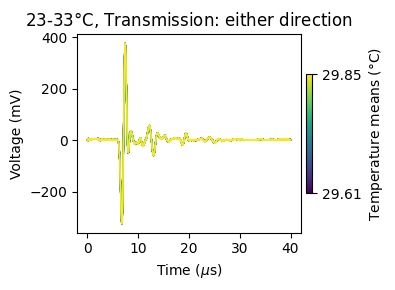

<Axes: title={'center': '23-33$\\degree$C, Transmission: either direction'}, xlabel='Time ($\\mu$s)', ylabel='Voltage (mV)'>

In [82]:
matplotlib_constrain_T(23, 33, 0, 0.5, heating='both', sort_by='means', index_range=(100,1100), direction='either',
                       save_fig_title='gradient_means_4x3.svg')


### Transducer on cold side

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_81828/2460072387.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


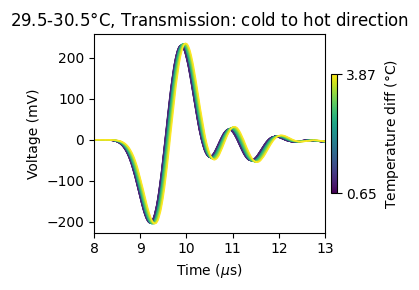

<Axes: title={'center': '29.5-30.5$\\degree$C, Transmission: cold to hot direction'}, xlabel='Time ($\\mu$s)', ylabel='Voltage (mV)'>

In [115]:
matplotlib_constrain_T(29.5,30.5, heating='both', sort_by='diff', index_range=(500,700), direction='forward', 
                       save_fig_title='gradient_c_to_h_4x3.svg')

### transducer on warm side

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_81828/2288953127.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


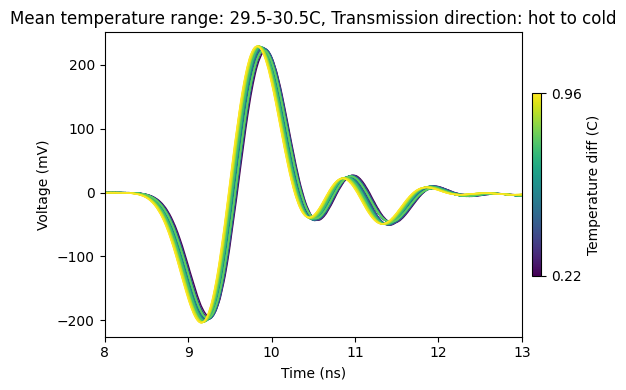

<Axes: title={'center': 'Mean temperature range: 29.5-30.5C, Transmission direction: hot to cold'}, xlabel='Time (ns)', ylabel='Voltage (mV)'>

In [97]:
matplotlib_constrain_T(29.5, 30.5, heating='both', sort_by='diff', index_range=(390,1100), direction='reverse',
                       save_fig_title='gradient_h_to_c_6x4.svg')


### compare thermal gradients with opposite signs

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_81828/2288953127.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


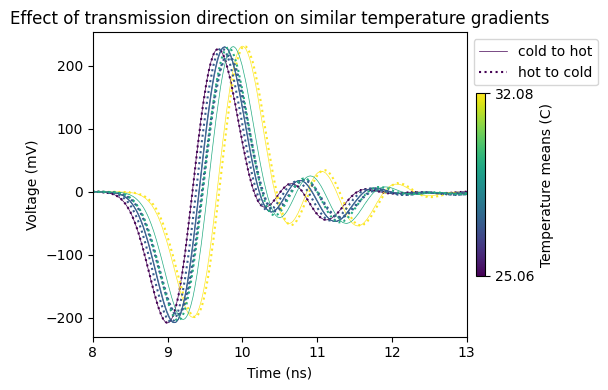

<Axes: title={'center': 'Effect of transmission direction on similar temperature gradients'}, xlabel='Time (ns)', ylabel='Voltage (mV)'>

In [93]:
matplotlib_constrain_T(heating='both', sort_by='means', direction='either', index_range=(100,1971), 
                       separate_diff_lines=True, samples=5, save_fig_title='./gradient_svgs/gradient_trans_dir_means_6x4.svg')

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_81828/2288953127.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


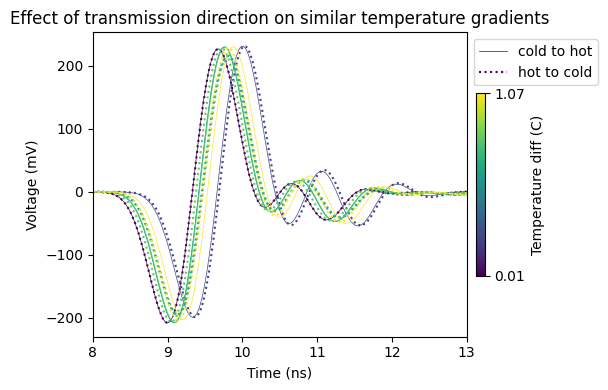

<Axes: title={'center': 'Effect of transmission direction on similar temperature gradients'}, xlabel='Time (ns)', ylabel='Voltage (mV)'>

In [94]:
matplotlib_constrain_T(heating='both', sort_by='diff', direction='either', index_range=(100,1971), 
                       separate_diff_lines=True, samples=5, save_fig_title='./gradient_svgs/gradient_trans_dir_diff_6x4.svg')